# 3b. Multi-Task Attention Extension

Extends the 4 attention models from [03_attention_exploration.ipynb](03_attention_exploration.ipynb)
with **deeper architectures** (depth=6 vs depth=4) and **longer training** (30 epochs vs 10):

- **Binary head**: benign vs. attack (weight 0.3)
- **Multiclass head**: 13 attack classes (weight 0.5)
- **Anomaly head**: continuous anomaly score (weight 0.2)

**Goal:** Check whether longer training and more capacity improves multi-task
performance over the shallow baselines in NB03.

The ensemble in NB04 builds on these results by routing inputs through
specialised experts with uncertainty-guided weighting.

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

from src.dataset import (
    create_flow_based_sequences,
    create_binary_labels,
    create_anomaly_scores,
    MultiTaskDataset,
)
from src.models import (
    TemporalAttentionTransformer,
    ProtocolAttentionTransformer,
    FeatureAttentionTransformer,
    CrossModalAttentionTransformer,
)
from src.training import train_attention_model
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 3b.1 Prepare Data

In [9]:
DATA_DIR = '../data'
SEQ_LEN  = 64
BATCH    = 32

X_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_X.csv')
y_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_y.csv').squeeze()
X_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_X.csv')
y_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_y.csv').squeeze()

X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()
for col in ['SimillarHTTP', 'SimilarHTTP']:
    if col in X_train.columns:
        X_train.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

X_seq_train, y_seq_train, proto_train, temp_train = create_flow_based_sequences(X_train, y_train_enc, seq_len=SEQ_LEN)
X_seq_test,  y_seq_test,  proto_test,  temp_test  = create_flow_based_sequences(X_test,  y_test_enc,  seq_len=SEQ_LEN)
feature_dim = X_seq_train.shape[-1]

y_bin_train  = create_binary_labels(y_seq_train, label_encoder)
y_bin_test   = create_binary_labels(y_seq_test,  label_encoder)
y_anom_train = create_anomaly_scores(y_seq_train, label_encoder)
y_anom_test  = create_anomaly_scores(y_seq_test,  label_encoder)

train_ds = MultiTaskDataset(X_seq_train, proto_train, temp_train,
                            y_seq_train, y_bin_train, y_anom_train)
test_ds  = MultiTaskDataset(X_seq_test,  proto_test,  temp_test,
                            y_seq_test,  y_bin_test,  y_anom_test)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f'Feature dim: {feature_dim} | Classes: {num_classes}')
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Feature dim: 43 | Classes: 13
Train batches: 96 | Test batches: 24


## 3b.2 Instantiate Models

In [10]:
model_configs = {
    'Temporal':   TemporalAttentionTransformer,
    'Protocol':   ProtocolAttentionTransformer,
    'Feature':    FeatureAttentionTransformer,
    'CrossModal': CrossModalAttentionTransformer,
}

models = {}
for name, cls in model_configs.items():
    m = cls(feature_dim=feature_dim, embed_dim=128, num_heads=8,
            transformer_depth=6, num_classes=num_classes).to(device)
    params = sum(p.numel() for p in m.parameters())
    models[name] = m
    print(f'{name:12s} : {params:>10,} parameters')

Temporal     :  1,466,160 parameters
Protocol     :  1,491,248 parameters
Feature      :  1,563,856 parameters
CrossModal   :  1,788,176 parameters


## 3b.3 Train All Models (Multi-Task)

In [11]:
EPOCHS = 30
all_results = {}

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')
    results = train_attention_model(
        model, name, train_loader, test_loader,
        num_classes=num_classes, device=device, epochs=EPOCHS,
    )
    all_results[name] = results
    bm = results['best_metrics']
    print(f'  Best epoch {results["best_epoch"]} — '
          f'Bin F1={bm["binary_f1"]:.4f} | '
          f'MC F1={bm["multiclass_f1"]:.4f} | '
          f'Anom Corr={bm["anomaly_corr"]:.4f} | '
          f'Combined={bm["combined_score"]:.4f}')


  Training: Temporal
Epoch  1/30  loss=0.7563  bin_f1=0.9777  mc_f1=0.7777  anom=0.8549  combined=0.8531
Epoch  2/30  loss=0.2811  bin_f1=0.9778  mc_f1=0.8164  anom=0.9473  combined=0.8910
Epoch  3/30  loss=0.2162  bin_f1=0.9830  mc_f1=0.8256  anom=0.9570  combined=0.8991
Epoch  4/30  loss=0.1923  bin_f1=0.9789  mc_f1=0.8117  anom=0.9656  combined=0.8927
Epoch  5/30  loss=0.1813  bin_f1=0.9761  mc_f1=0.8511  anom=0.9658  combined=0.9115
Epoch  6/30  loss=0.1724  bin_f1=0.9791  mc_f1=0.8783  anom=0.9548  combined=0.9238
Epoch  7/30  loss=0.1594  bin_f1=0.9765  mc_f1=0.9051  anom=0.9599  combined=0.9375
Epoch  8/30  loss=0.1479  bin_f1=0.9829  mc_f1=0.8612  anom=0.9682  combined=0.9191
Epoch  9/30  loss=0.1315  bin_f1=0.9856  mc_f1=0.9206  anom=0.9688  combined=0.9497
Epoch 10/30  loss=0.1270  bin_f1=0.9816  mc_f1=0.9194  anom=0.9696  combined=0.9481
Epoch 11/30  loss=0.1225  bin_f1=0.9816  mc_f1=0.9252  anom=0.9694  combined=0.9510
Epoch 12/30  loss=0.1175  bin_f1=0.9882  mc_f1=0.9223 

## 3b.4 Compare Results

In [12]:
rows = []
for name, res in all_results.items():
    bm = res['best_metrics']
    rows.append({
        'Model': name,
        'Best Epoch': res['best_epoch'],
        'Binary F1': bm['binary_f1'],
        'Multiclass F1': bm['multiclass_f1'],
        'Anomaly Corr': bm['anomaly_corr'],
        'Combined Score': bm['combined_score'],
    })

comparison_df = pd.DataFrame(rows).sort_values('Combined Score', ascending=False)
print(comparison_df.to_string(index=False, float_format='%.4f'))

     Model  Best Epoch  Binary F1  Multiclass F1  Anomaly Corr  Combined Score
CrossModal          28     0.9882         0.9455        0.9750          0.9642
  Temporal          13     0.9856         0.9483        0.9691          0.9637
   Feature          19     0.9895         0.9388        0.9672          0.9597
  Protocol          17     0.9855         0.9364        0.9672          0.9573


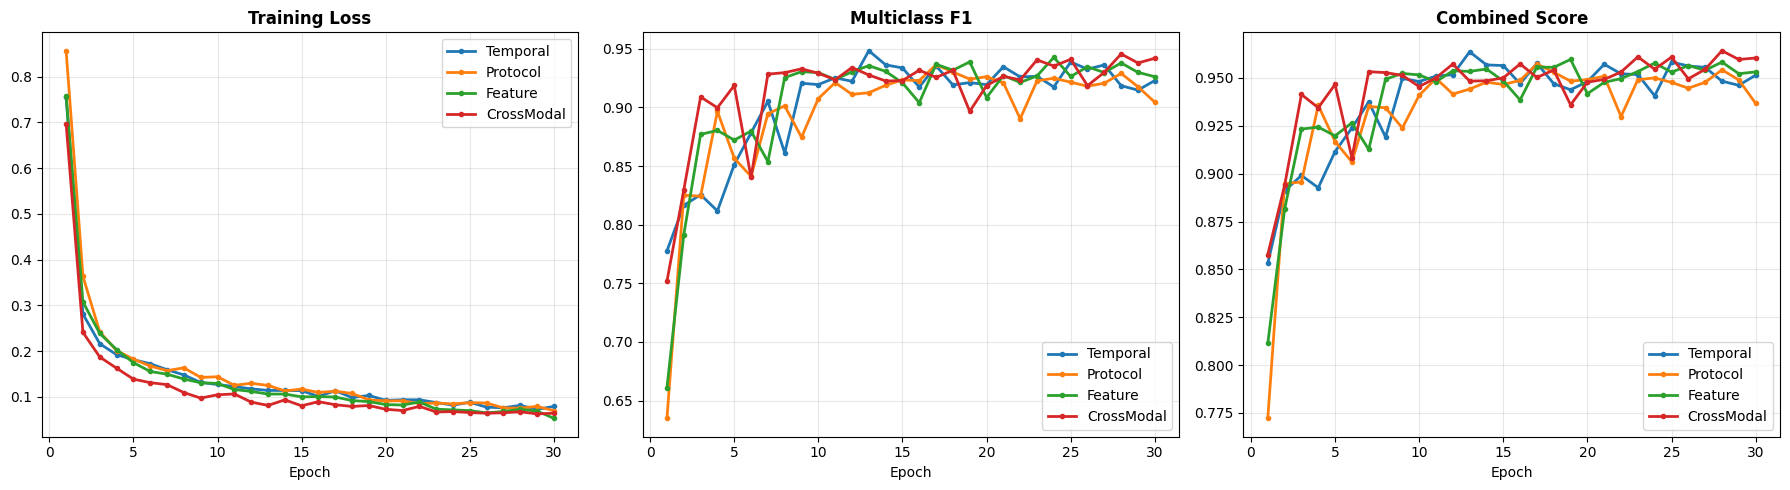

In [13]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, res) in enumerate(all_results.items()):
    ep = range(1, len(res['val_metrics']) + 1)
    axes[0].plot(ep, res['train_losses'], 'o-', color=colors[i],
                 label=name, linewidth=2, markersize=3)
    mc_f1 = [m['multiclass_f1'] for m in res['val_metrics']]
    axes[1].plot(ep, mc_f1, 'o-', color=colors[i],
                 label=name, linewidth=2, markersize=3)
    cs = [m['combined_score'] for m in res['val_metrics']]
    axes[2].plot(ep, cs, 'o-', color=colors[i],
                 label=name, linewidth=2, markersize=3)

for ax, title in zip(axes, ['Training Loss', 'Multiclass F1', 'Combined Score']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/attention_multitask_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

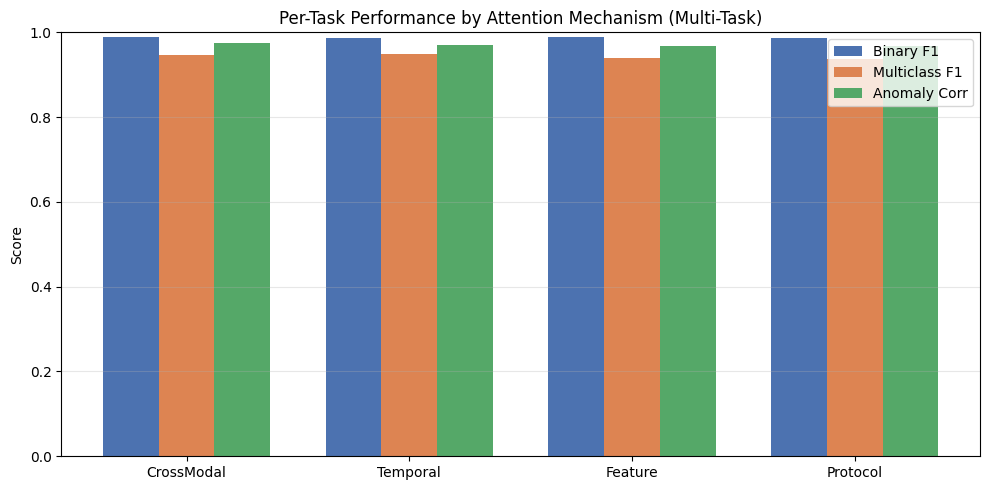

In [14]:
# Bar chart — per-task performance
names = comparison_df['Model'].tolist()
x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, comparison_df['Binary F1'],     w, label='Binary F1',     color='#4c72b0')
ax.bar(x,     comparison_df['Multiclass F1'],  w, label='Multiclass F1', color='#dd8452')
ax.bar(x + w, comparison_df['Anomaly Corr'],   w, label='Anomaly Corr',  color='#55a868')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Score')
ax.set_title('Per-Task Performance by Attention Mechanism (Multi-Task)')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/attention_multitask_pertask.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b.5 Observations

Comparing NB03 (depth=4, 10 epochs) vs. NB03b (depth=6, 30 epochs):

| Setting | Best MC F1 | Best Binary F1 | Best Anom Corr | Best Combined |
|---|---|---|---|---|
| NB03 (depth=4, 10ep) | 0.9321 (CrossModal) | 0.9868 (Feature) | 0.9711 (Feature) | 0.9538 (CrossModal) |
| NB03b (depth=6, 30ep) | **0.9483** (Temporal) | **0.9895** (Feature) | **0.9750** (CrossModal) | **0.9642** (CrossModal) |

**Interpretation:** Deeper models (depth=6) and longer training (30 epochs) provide a
consistent ~1pp improvement across all metrics. Cross-Modal and Temporal attention both
scale well with depth.

Notably, Temporal attention overtakes Cross-Modal on pure MC F1 at depth=6 (~0.948 vs ~0.946),
suggesting that temporal burst patterns become more discriminative with greater model capacity.

**The ensemble in NB04** combines all three specialist experts (Temporal, Protocol, Feature)
with learned gating, aiming to exceed any single expert by routing each input to the most
relevant specialist.

**Next step -> [04_ensemble_model.ipynb](04_ensemble_model.ipynb):** Build the advanced ensemble.